# KNN Classification: use Titanic Dataset
- Dataset: Titanic Dataset
  - [Kaggle Titanic Dataset](https://www.kaggle.com/c/titanic/data)
- Goal: Predict survival on the Titanic
- Features:
  - Pclass: Passenger class (1st, 2nd, 3rd)
  - Sex: Gender (male, female)
- Data content: 891 rows × 12 columns
- Columns:PassengerId, Survived, Pclass(艙等), Name, Sex, Age, SibSp(兄弟姐妹/配偶數), Parch(父母/子女數), Ticket(票號), Fare(票價), Cabin(客艙編號), Embarked(登船港口)

In [1]:
from pathlib import Path
import pandas as pd

# Import dataset and understand data

In [2]:
source_path = Path("../csv/titanic/train.csv")
df = pd.read_csv(source_path)
df.head()
df.info()
df.describe()
# df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Preprocessing
- Handle missing values
- Convert categorical variables to numerical format
- Feature scaling
- Split the dataset into training and testing sets

### Handle Missing Values

In [3]:
df.isnull().sum()
df.isnull().sum() / df.isnull().count()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) # 使用平均值填補年齡的缺失值
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # 使用眾數填補登船港口的缺失值
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin']) # 刪除艙位欄位
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

### Handle Duplicates

In [5]:
df[df.duplicated()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


### Convert Categorical Variables to Numerical Format

In [6]:
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0


# EDA

<Axes: title={'center': 'Survival Counts'}, ylabel='count'>

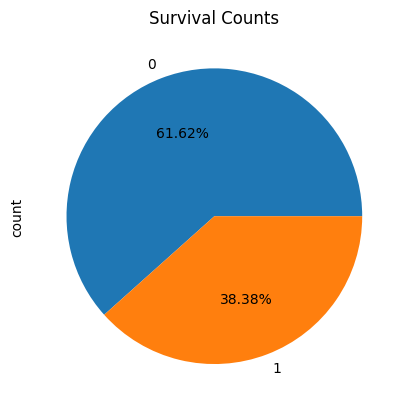

In [7]:
df['Survived'].value_counts()
df['Survived'].value_counts().plot(kind='pie', autopct='%1.2f%%', title='Survival Counts')

<Axes: title={'center': 'Gender Counts'}, ylabel='count'>

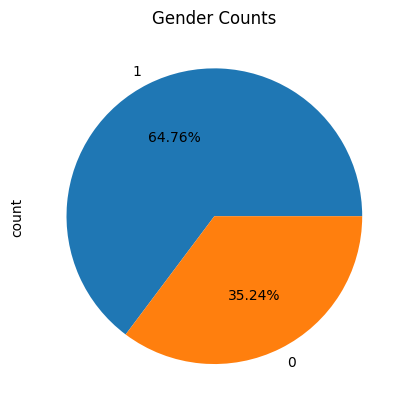

In [8]:
df['Sex'].value_counts()
df['Sex'].value_counts().plot(kind='pie', autopct='%1.2f%%', title='Gender Counts')

<Axes: title={'center': 'Passenger Class Counts'}, ylabel='count'>

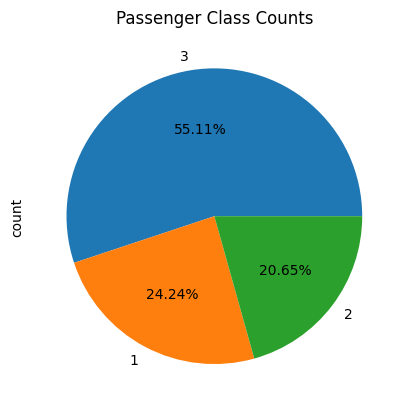

In [9]:
df['Pclass'].value_counts()
df['Pclass'].value_counts().plot(kind='pie', autopct='%1.2f%%', title='Passenger Class Counts')

In [10]:
df.groupby(['Sex'])['PassengerId'].count()

Sex
0    314
1    577
Name: PassengerId, dtype: int64

<Axes: title={'center': 'Survival Counts by Gender'}, xlabel='Sex,Survived'>

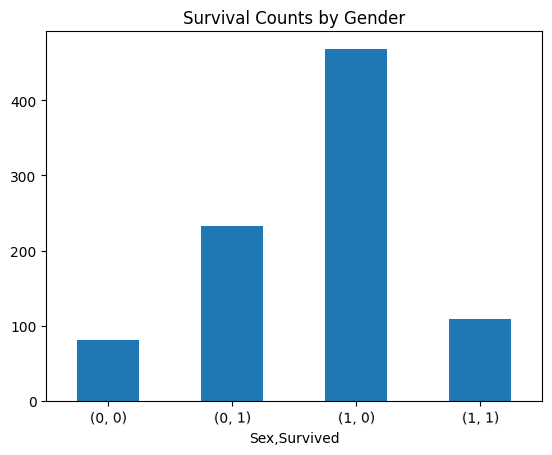

In [11]:
df.groupby(['Sex','Survived'])['PassengerId'].count()
df.groupby(['Sex','Survived'])['PassengerId'].count().plot(kind='bar', rot=1, title='Survival Counts by Gender')

In [12]:
ss = df.groupby(['Sex','Survived'])['PassengerId'].count() / df.groupby(['Sex'])['PassengerId'].count()
ss

Sex  Survived
0    0           0.257962
     1           0.742038
1    0           0.811092
     1           0.188908
Name: PassengerId, dtype: float64

<Axes: title={'center': 'Survival Rate by Gender'}, xlabel='Sex,Survived'>

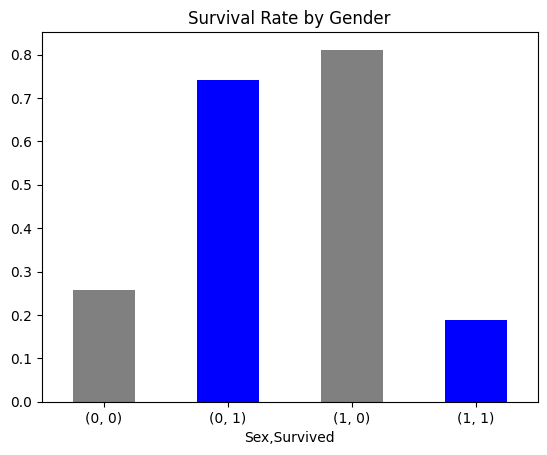

In [13]:
ss.plot(kind='bar', color=['grey', 'blue'], rot=0, title='Survival Rate by Gender')

<Axes: title={'center': 'Survival Counts by Passenger Class'}, xlabel='Pclass,Survived'>

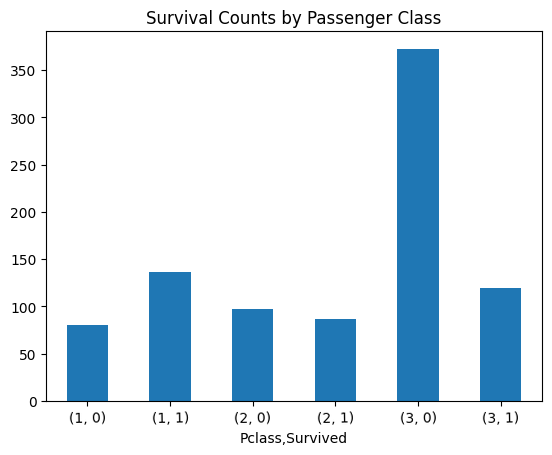

In [14]:
df.groupby(['Pclass','Survived'])['PassengerId'].count()
df.groupby(['Pclass','Survived'])['PassengerId'].count().plot(kind='bar', rot=1, title='Survival Counts by Passenger Class')

In [15]:
ps = df.groupby(['Pclass','Survived'])['PassengerId'].count() / df.groupby(['Pclass'])['PassengerId'].count()
ps

Pclass  Survived
1       0           0.370370
        1           0.629630
2       0           0.527174
        1           0.472826
3       0           0.757637
        1           0.242363
Name: PassengerId, dtype: float64

<Axes: title={'center': 'Survival Rate by Passenger Class'}, xlabel='Pclass,Survived'>

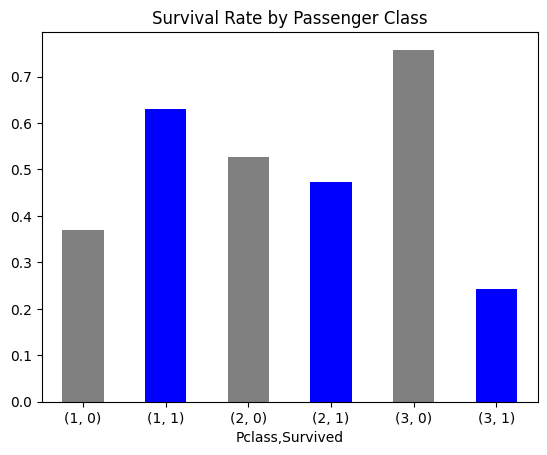

In [16]:
ps.plot(kind='bar', color=['grey', 'blue'], rot=0, title='Survival Rate by Passenger Class')

# Build KNN Model
- Import KNN Classifier
- Train the model
- Make predictions

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [22]:
# Define features and target variable
df_X = df[['Sex', 'Pclass']]
df_y = df['Survived']
df_X.head()
df_y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [31]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=42)

In [32]:
# Build KNN Model
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)


,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
print('----KNN Model Evaluation based on accuracy of test dataset----')
print(f'KNN Model (k={k}) Testing Accuracy: {knn.score(X_test, y_test):.4f}')

----KNN Model Evaluation based on accuracy of test dataset----
KNN Model (k=1) Testing Accuracy: 0.7821


In [34]:
s = []
for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    s.append((i, acc))
    print(f'KNN Model (k={i}) Testing Accuracy: {acc:.4f}')

KNN Model (k=1) Testing Accuracy: 0.7821
KNN Model (k=2) Testing Accuracy: 0.7654
KNN Model (k=3) Testing Accuracy: 0.7821
KNN Model (k=4) Testing Accuracy: 0.7654
KNN Model (k=5) Testing Accuracy: 0.7654
KNN Model (k=6) Testing Accuracy: 0.7654
KNN Model (k=7) Testing Accuracy: 0.7821
KNN Model (k=8) Testing Accuracy: 0.7821
KNN Model (k=9) Testing Accuracy: 0.7821
KNN Model (k=10) Testing Accuracy: 0.7654


In [35]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
print('----KNN Model Prediction----')
pred = knn.predict(X_test)
print(pred)
print('----Actual Values----')
print(str(y_test.values))

----KNN Model Prediction----
[0 0 0 1 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1]
----Actual Values----
[1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 0 1
 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 1 1
 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1]


In [43]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred)
print(f'KNN Model (k=7) Prediction Accuracy: {accuracy:.4f}')

KNN Model (k=7) Prediction Accuracy: 0.7821


In [44]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, pred)
print('----Confusion Matrix----')
print(conf_matrix)


----Confusion Matrix----
[[88 17]
 [22 52]]


In [50]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(knn, X_train, y_train, scoring='accuracy', cv=10)
print("Accuracy from each fold:")
print(scores.round(2))
print('Average Accuracy:', scores.mean().round(2))
print('Max Accuracy:', scores.max().round(2))
print('Min Accuracy:', scores.min().round(2))


Accuracy from each fold:
[0.82 0.75 0.69 0.89 0.82 0.68 0.79 0.77 0.76 0.89]
Average Accuracy: 0.79
Max Accuracy: 0.89
Min Accuracy: 0.68


In [57]:
Rose = pd.DataFrame({'Sex': [0], 'Pclass': [1]})
v = knn.predict(Rose)
if v == 1:
    print('Rose would have survived.')
else:
    print('Rose would not have survived.')

Rose would have survived.


In [58]:
Jack = pd.DataFrame({'Sex': [1], 'Pclass': [3]})
v = knn.predict(Jack)
if v == 1:
    print('Jack would have survived.')
else:
    print('Jack would not have survived.')

Jack would not have survived.
